In [1]:
print("과제 3")

과제 3


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [3]:
data = load_iris(as_frame=True)

df = data.frame.copy()
df["species"] = df["target"].map(dict(enumerate(data.target_names)))

X = data.data
y = data.target

print("데이터 크기:", X.shape)
print("특성 이름:", data.feature_names)
print("클래스 이름:", data.target_names)
print("클래스 분포:")
print(df["species"].value_counts())

데이터 크기: (150, 4)
특성 이름: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
클래스 이름: ['setosa' 'versicolor' 'virginica']
클래스 분포:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


In [4]:
pd.set_option("display.max_columns", None)

print(df[data.feature_names].describe())

print(df.groupby("species")[data.feature_names].mean().round(2))

       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)  
count        150.000000  
mean           1.199333  
std            0.762238  
min            0.100000  
25%            0.300000  
50%            1.300000  
75%            1.800000  
max            2.500000  
            sepal length (cm)  sepal width (cm)  petal length (cm)  \
species                                                              
setosa                   5.01           

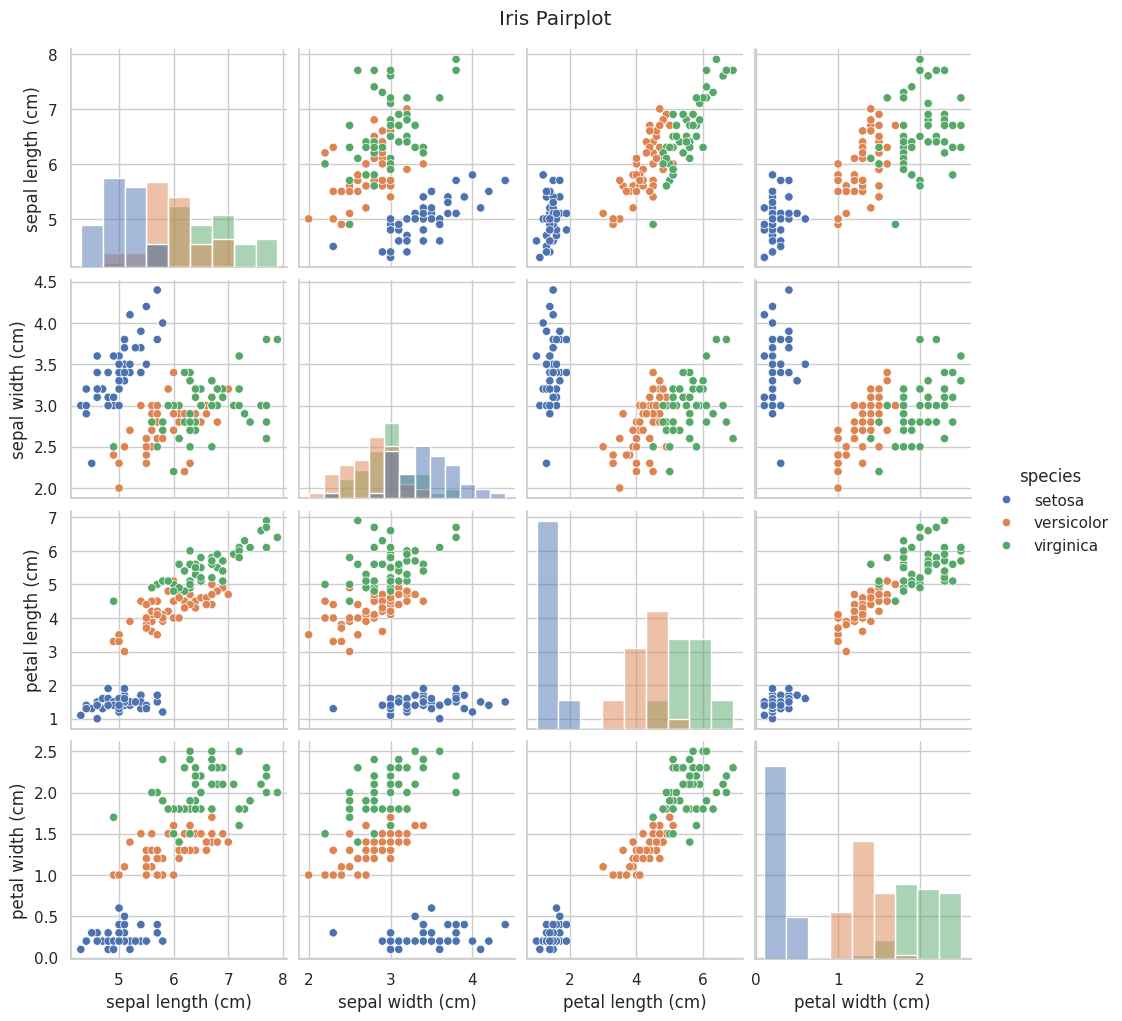

In [5]:
sns.set_theme(style="whitegrid")

pair = sns.pairplot(
    df,
    vars=data.feature_names,
    hue="species",
    diag_kind="hist"
)

pair.fig.suptitle("Iris Pairplot", y=1.02)
plt.show()

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("학습 데이터 크기:", X_train.shape)
print("테스트 데이터 크기:", X_test.shape)

학습 데이터 크기: (105, 4)
테스트 데이터 크기: (45, 4)


In [7]:
scaler = StandardScaler()

X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)

print("표준화된 학습 데이터 일부:")
print(X_train_std[:5])

표준화된 학습 데이터 일부:
[[-0.90045861 -1.22024754 -0.4419858  -0.13661044]
 [ 0.38036614 -1.87955796  0.40282929  0.38029394]
 [-0.90045861  1.63676428 -1.2868009  -1.17041921]
 [ 1.07899781  0.31814344  1.19132338  1.41410271]
 [-0.20182693 -0.56093712  0.17754527  0.12184175]]


In [8]:
pca = PCA(n_components=4)

X_train_pca_all = pca.fit_transform(X_train_std)
X_test_pca_all = pca.transform(X_test_std)

print("PCA 설명된 분산 비율:")
for i, ratio in enumerate(pca.explained_variance_ratio_, start=1):
    print(f"PC{i}: {ratio:.4f}")

print("누적 설명 분산 비율:")
print(np.cumsum(pca.explained_variance_ratio_))

PCA 설명된 분산 비율:
PC1: 0.7264
PC2: 0.2338
PC3: 0.0352
PC4: 0.0046
누적 설명 분산 비율:
[0.7264421  0.96022997 0.99541737 1.        ]


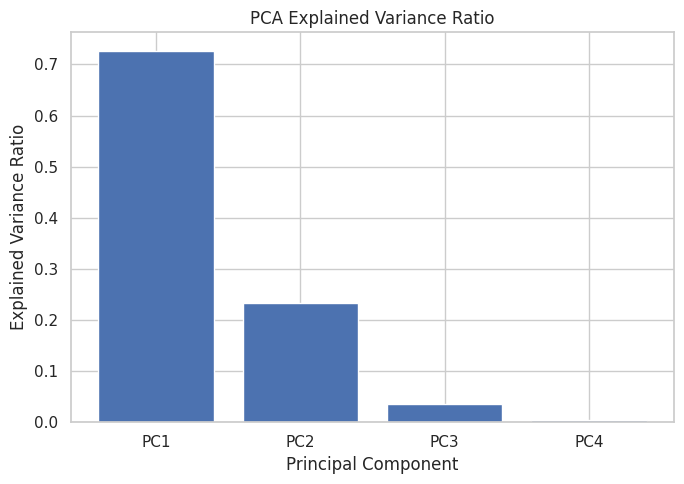

In [9]:
plt.figure(figsize=(7, 5))
plt.bar(
    [f"PC{i}" for i in range(1, 5)],
    pca.explained_variance_ratio_
)

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("PCA Explained Variance Ratio")
plt.tight_layout()
plt.show()

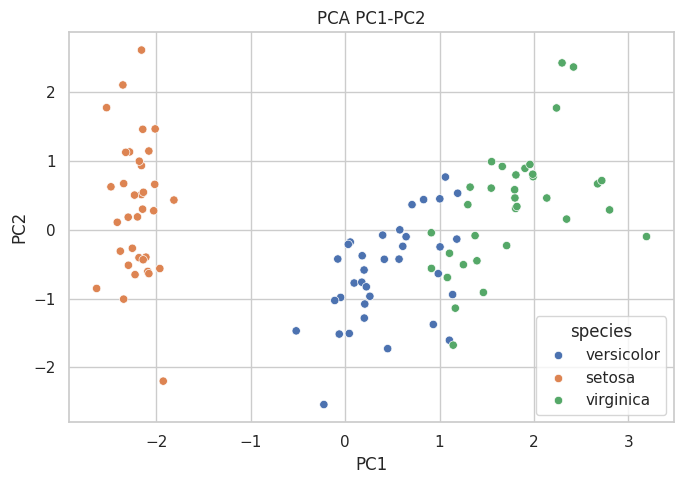

In [10]:
pca_df = pd.DataFrame(
    X_train_pca_all,
    columns=["PC1", "PC2", "PC3", "PC4"]
)

pca_df["species"] = [data.target_names[i] for i in y_train]

plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="species"
)
plt.title("PCA PC1-PC2")
plt.tight_layout()
plt.show()

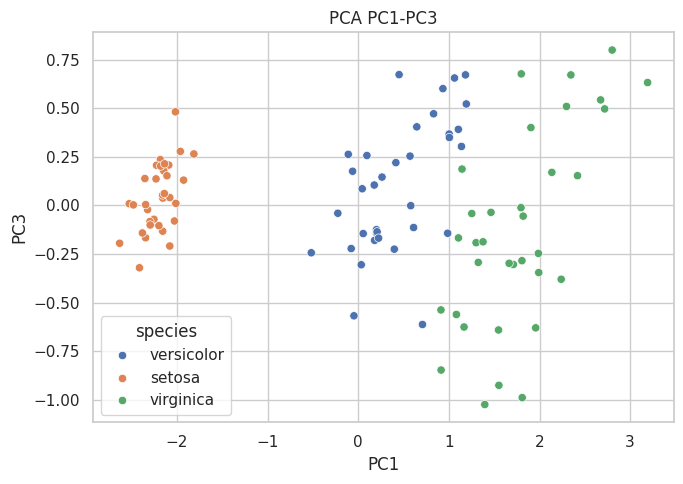

In [11]:
plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC3",
    hue="species"
)
plt.title("PCA PC1-PC3")
plt.tight_layout()
plt.show()

In [12]:
# 1. PCA PC1-PC2
X_train_pc12 = X_train_pca_all[:, [0, 1]]
X_test_pc12 = X_test_pca_all[:, [0, 1]]

# 2. PCA PC1-PC3
X_train_pc13 = X_train_pca_all[:, [0, 2]]
X_test_pc13 = X_test_pca_all[:, [0, 2]]

# 3. PCA PC1~PC3
X_train_pc123 = X_train_pca_all[:, [0, 1, 2]]
X_test_pc123 = X_test_pca_all[:, [0, 1, 2]]

# 4. 스케일링된 원본 4차원 데이터
X_train_4d = X_train_std
X_test_4d = X_test_std

# 5. Sepal Width + Petal Width
# feature index: sepal width = 1, petal width = 3
X_train_sw_pw = X_train_std[:, [1, 3]]
X_test_sw_pw = X_test_std[:, [1, 3]]

In [13]:
datasets = {
    "PCA PC1-PC2": (X_train_pc12, X_test_pc12),
    "PCA PC1-PC3": (X_train_pc13, X_test_pc13),
    "PCA PC1~PC3": (X_train_pc123, X_test_pc123),
    "Scaled Original 4D": (X_train_4d, X_test_4d),
    "Sepal Width + Petal Width": (X_train_sw_pw, X_test_sw_pw)
}

neighbors = range(1, 16)

results = []

for name, (Xtr, Xte) in datasets.items():
    for k in neighbors:
        knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(Xtr, y_train)

        y_pred = knn.predict(Xte)
        acc = accuracy_score(y_test, y_pred)

        results.append({
            "case": name,
            "k": k,
            "accuracy": acc
        })

result_df = pd.DataFrame(results)

print(result_df)

                         case   k  accuracy
0                 PCA PC1-PC2   1  0.933333
1                 PCA PC1-PC2   2  0.911111
2                 PCA PC1-PC2   3  0.911111
3                 PCA PC1-PC2   4  0.866667
4                 PCA PC1-PC2   5  0.911111
..                        ...  ..       ...
70  Sepal Width + Petal Width  11  0.955556
71  Sepal Width + Petal Width  12  0.933333
72  Sepal Width + Petal Width  13  0.933333
73  Sepal Width + Petal Width  14  0.933333
74  Sepal Width + Petal Width  15  0.933333

[75 rows x 3 columns]


In [14]:
best_result = result_df.loc[
    result_df.groupby("case")["accuracy"].idxmax()
].sort_values("accuracy", ascending=False)

print("케이스별 최고 성능:")
print(best_result)

케이스별 최고 성능:
                         case  k  accuracy
15                PCA PC1-PC3  1  0.955556
53         Scaled Original 4D  9  0.955556
38                PCA PC1~PC3  9  0.955556
67  Sepal Width + Petal Width  8  0.955556
0                 PCA PC1-PC2  1  0.933333


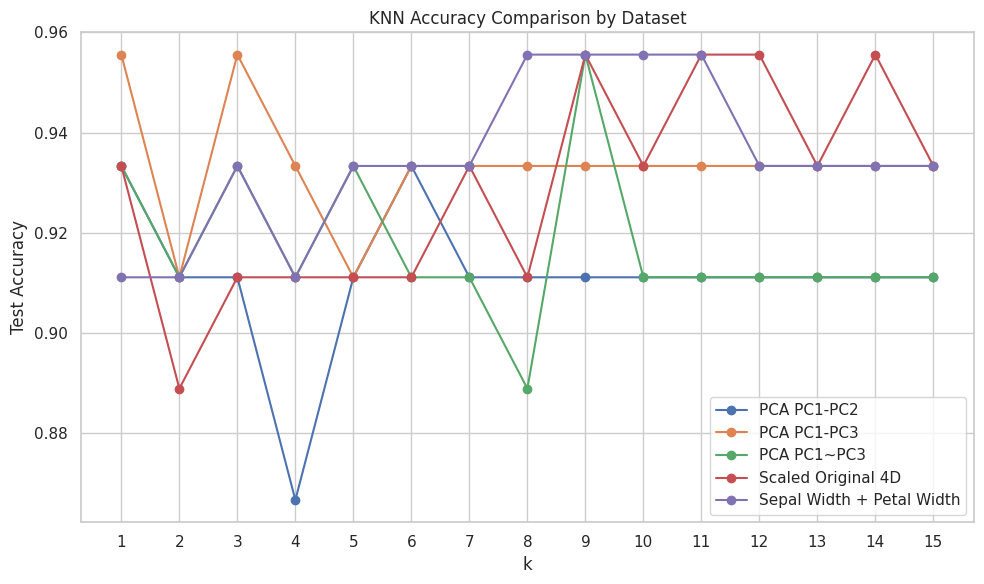

In [15]:
plt.figure(figsize=(10, 6))

for name in datasets.keys():
    temp = result_df[result_df["case"] == name]
    plt.plot(
        temp["k"],
        temp["accuracy"],
        marker="o",
        label=name
    )

plt.xlabel("k")
plt.ylabel("Test Accuracy")
plt.title("KNN Accuracy Comparison by Dataset")
plt.xticks(list(neighbors))
plt.legend()
plt.tight_layout()
plt.show()

In [16]:
best_case = best_result.iloc[0]["case"]
best_k = int(best_result.iloc[0]["k"])
best_acc = best_result.iloc[0]["accuracy"]

print("최고 성능 케이스:", best_case)
print("최적 k:", best_k)
print("최고 정확도:", round(best_acc, 4))

Xtr_best, Xte_best = datasets[best_case]

best_knn = KNeighborsClassifier(n_neighbors=best_k)
best_knn.fit(Xtr_best, y_train)

y_pred_best = best_knn.predict(Xte_best)

cm = confusion_matrix(y_test, y_pred_best)

print("혼동행렬:")
print(cm)

print("분류 보고서:")
print(classification_report(y_test, y_pred_best, target_names=data.target_names))

최고 성능 케이스: PCA PC1-PC3
최적 k: 1
최고 정확도: 0.9556
혼동행렬:
[[15  0  0]
 [ 0 14  1]
 [ 0  1 14]]
분류 보고서:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.93      0.93      0.93        15
   virginica       0.93      0.93      0.93        15

    accuracy                           0.96        45
   macro avg       0.96      0.96      0.96        45
weighted avg       0.96      0.96      0.96        45



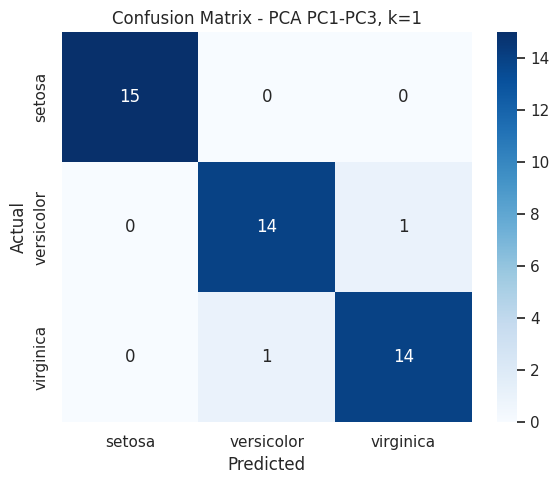

In [17]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=data.target_names,
    yticklabels=data.target_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix - {best_case}, k={best_k}")
plt.tight_layout()
plt.show()